In [ ]:
import requests
url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
words = requests.get(url).text.splitlines()


In [ ]:
print(words[:10])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [ ]:
len(words)

32033

In [ ]:
min(len(w) for w in words)

2

In [ ]:
max(len(w) for w in words)

15

In [ ]:
b = {}
for w in words:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1


In [ ]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
import torch
N = torch.zeros((27, 27), dtype=torch.int32)

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [ ]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1


KeyError: 26

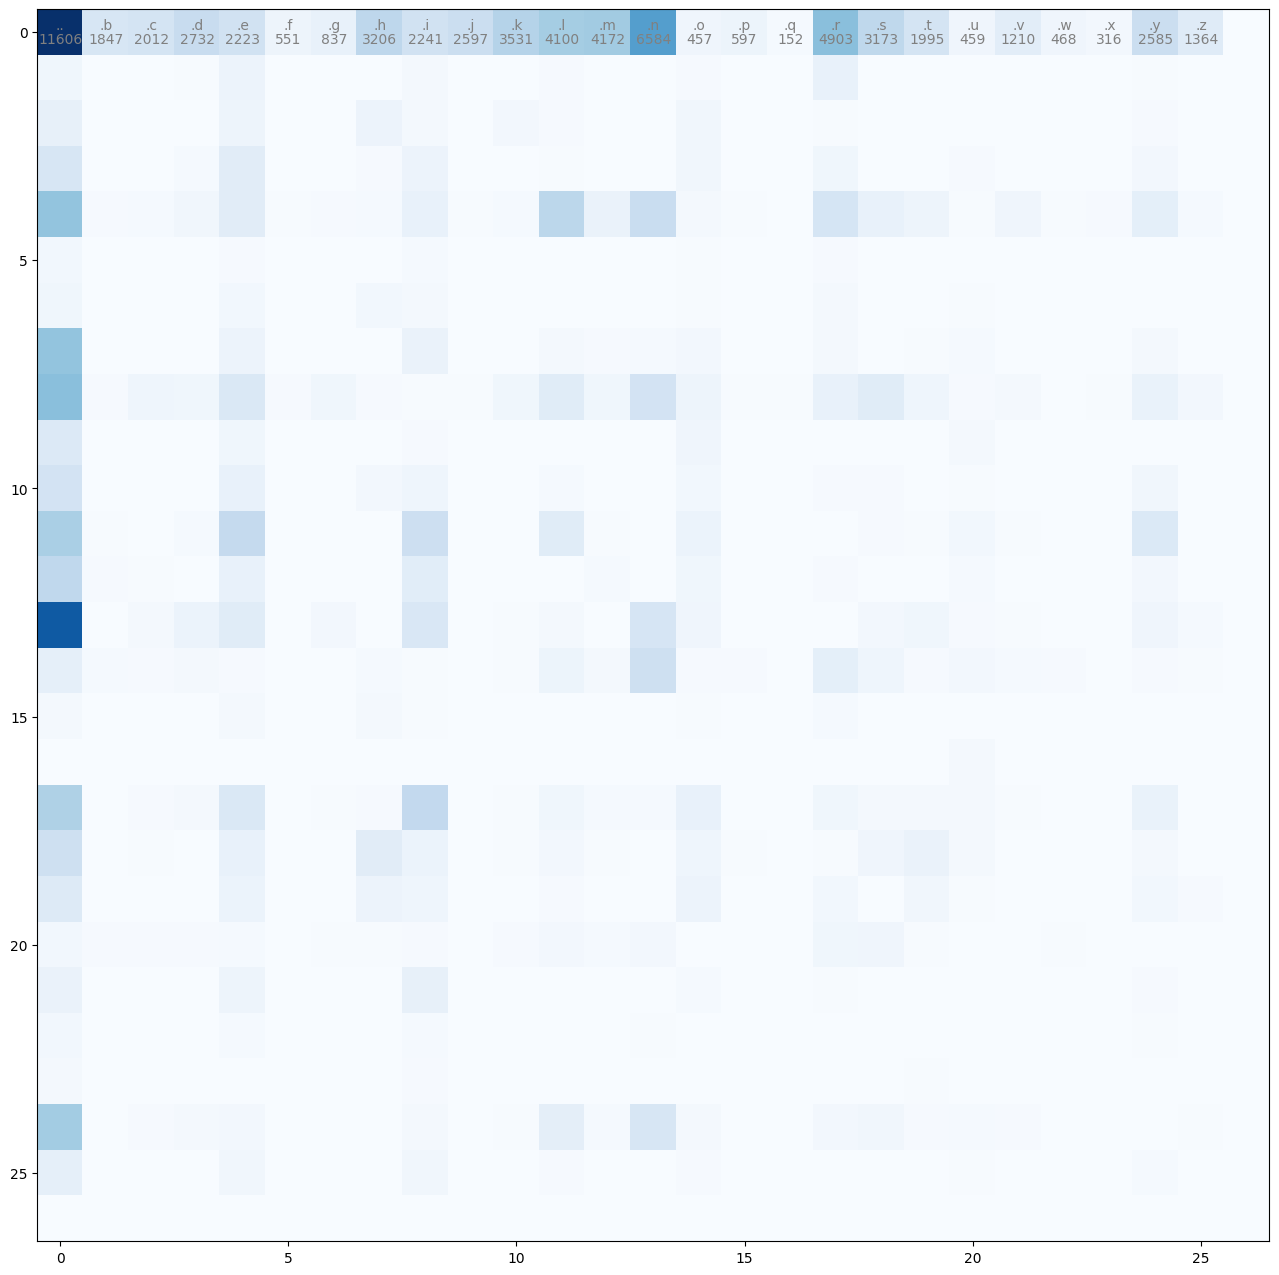

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [ ]:
N[0]

tensor([11606,  1847,  2012,  2732,  2223,   551,   837,  3206,  2241,  2597,
         3531,  4100,  4172,  6584,   457,   597,   152,  4903,  3173,  1995,
          459,  1210,   468,   316,  2585,  1364,     0], dtype=torch.int32)

In [ ]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.1761, 0.0280, 0.0305, 0.0414, 0.0337, 0.0084, 0.0127, 0.0486, 0.0340,
        0.0394, 0.0536, 0.0622, 0.0633, 0.0999, 0.0069, 0.0091, 0.0023, 0.0744,
        0.0481, 0.0303, 0.0070, 0.0184, 0.0071, 0.0048, 0.0392, 0.0207, 0.0000])

In [ ]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g).item()
itos[ix]

'd'

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
# normailiaing the vector p
p


tensor([0.6064, 0.3033, 0.0903])

In [ ]:
torch.multinomial(p, num_samples=10, replacement=True, generator=g)


tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0])

In [ ]:
p.shape

torch.Size([3])

In [ ]:
p.sum(1, keepdims=True).shape

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [ ]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [ ]:
P.shape

In [ ]:
P.sum(1, keepdim=True).shape

In [ ]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [ ]:
#  27, 27
#  1, 27


In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):

  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    # itos is for inedx to string ......
    if ix == 0:
      break
    print(''.join(out))



d
dr
dry
n
n
ni
nin
nini
ninil
ninilv
ninilvi
ninilvil
d
dr
dri
dril
y
yi
yie
yien
yienn


In [ ]:
 #GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)


In [ ]:
log_likelihood = 0.0
n = 0

for w in words:
# for w in ['andrejq']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    # print(f'c{ch1}{ch2}; {prob:.4f} {logprob: 4f}')
print(f'{log_likelihood}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')


-533760.625
nll=tensor(533760.6250)
2.33955717086792


In [ ]:
# create a training set of bigrams (x, y)
xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [ ]:
xs

tensor([ 0,  4, 12, 12,  0])

In [ ]:
ys

tensor([ 4, 12, 12,  0,  0])

When the model sees character xs[i], the correct next character is ys[i].



In [ ]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
xenc.shape

torch.Size([5, 27])

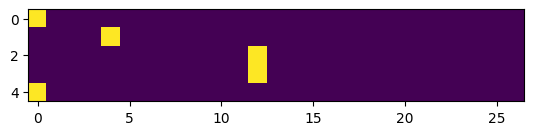

In [ ]:
plt.imshow(xenc)

In [ ]:
xenc.dtype

torch.float32

In [ ]:
xenc.shape

torch.Size([5, 27])

In [ ]:


W = torch.randn((27, 1))
xenc @ W # this is the same as matmul
# which can be written as: logits = torch.matmul(xenc, W)

tensor([[-1.7960],
        [ 1.3340],
        [ 0.8595],
        [ 0.8595],
        [-1.7960]])

In [ ]:
logits = xenc @ W # log-counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs


tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])

In [ ]:
probs[0]

tensor([1.])

In [ ]:
probs[0].shape

torch.Size([1])

In [ ]:
probs[0].sum()

tensor(1.)

In [ ]:
xs

tensor([ 0,  4, 12, 12,  0])

In [ ]:
ys

tensor([ 4, 12, 12,  0,  0])

In [ ]:
# randomly initialize 27 neurons weights , each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27, 27), generator=g)

In [ ]:
xenc = F.one_hot(xs, num_classes=27).float()   # input to the network: noe-hot encoding
logits =  xenc @ W  # predict log-counts
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)   #this sums the first row
# probabilities for next character
# btw : the last 2 lines here are together called a 'softmax'

In [ ]:
probs.shape

torch.Size([5, 1])

In [ ]:
nlls = torch.zeros(5)   # 1D tensor with 5 entries (where the enries are 0s).

for i in range(5):
  x = xs[i].item()
  y = ys[i].item()
  print('--------------')
  print(f" bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})")
  print('input to the neural net:', x)
  print('output probabiltites from the neural net:',  probs[i])
  print('label (actual next character): ', y)
  p = probs[i, y]
  print("probabilities assigend by the net to the correct character ", p.item())
  logp = torch.log(p)
  print('negative likelihood', logp.item())
  nlls[i] = nll

  print('======================')
  print('Average negative log likelihood , i.e, loss = ', nlls.mean().item())



--------------
 bigram example 1: .e (indexes 0, 4)
input to the neural net: 0
output probabiltites from the neural net: tensor([1.])
label (actual next character):  4


IndexError: index 4 is out of bounds for dimension 1 with size 1

In [ ]:
xs

In [ ]:
ys

In [ ]:
probs.shape

In [ ]:
# randomly initialize 27 neurons weights each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27, 27), generator=g, requires_grad=True)


In [ ]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(5), ys].log().mean()

In [ ]:
print(loss.item())

In [ ]:
w.grad = None  # set to zero gradient
# setting the grad to zero is really an important step

loss.backeeard()



In [ ]:
w.data += -0.1 * w.grad

Now it is time for optimization ....!!!!

In [ ]:
xs, ys = [] , []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num =  xs.nelement()
print('Number of example', num)

# Initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
w = torch.rand((27, 27), generator=g, requires_grad=True)


In [ ]:
# Gradient descent
for k in range(1):


  # Forward pass
  xenc = F.one_hot(xs, num_classes=27).float()
  logits = xenc @ w
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdims=True)
  loss = -prob[torch.arange(num), ys].log().mean() + 0.01*(w**2).mean()

  print(loss.item())

  # backward pass
  w.grad =  None
  loss.backward()

  w.data += -50 * w.grad


In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):

  out = []
  ix = 0
  while True:

    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ w   # predivt the log-counts
    counts = logits.exp()    # counts equivalent to N
    p = counts / counts.sum(1, keepdims=True)

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
    print(''.join(out))